In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [21]:
# ============================================================
# 1. Load raw data
# ============================================================
data_raw = pd.read_csv('../data/raw/data.csv', parse_dates=['Period'], index_col='Period')

# ============================================================
# 2. Chọn các biến chỉ numeric, bỏ Period, Year, Month, Quarter
# ============================================================
vars_for_desc = [
    'FDI (billion USD)', 'EX (USD)', 'IM (USD)',
    'CPI_US (2010 = 100)', 'CPI_VN (2010 = 100)', 'REER (2007M12 = 100)', 'NER',
    'IPI VN (2015 = 100)', 'IPI World (2015 = 100)', 'COVID',
    'WTI Spot Price FOB (Dollars per Barrel)', 'M2 (billion VND)'
]
data_desc = data_raw[vars_for_desc]

In [22]:
# ============================================================
# 3. Tính descriptive statistics
# ============================================================
desc_stats = data_desc.describe().T
# thêm skewness và kurtosis
import numpy as np
desc_stats['skew'] = data_desc.skew()
desc_stats['kurtosis'] = data_desc.kurtosis()

# làm tròn
desc_stats = desc_stats[['mean','std','min','max','skew','kurtosis']].round(4)

In [23]:
# ============================================================
# 4. Xuất LaTeX longtable đẹp
# ============================================================
# escape underscore trong tên biến
desc_stats_escaped = desc_stats.copy()
desc_stats_escaped.index = [idx.replace('_', r'\_') for idx in desc_stats_escaped.index]

latex_table = desc_stats_escaped.to_latex(
    caption="Descriptive Statistics for all variables",
    label="tab:desc_stats",
    header=['Mean','Std','Min','Max','Skewness','Kurtosis'],
    index=True,
    float_format="%.4f",
    longtable=True
)

output_file = "../results/descriptive_statistics.tex"
with open(output_file, "w") as f:
    f.write(latex_table)

print(f"Descriptive statistics table saved to {output_file}")
print(latex_table)

Descriptive statistics table saved to ../results/descriptive_statistics.tex
\begin{longtable}{lrrrrrr}
\caption{Descriptive Statistics for all variables} \label{tab:desc_stats} \\
\toprule
 & Mean & Std & Min & Max & Skewness & Kurtosis \\
\midrule
\endfirsthead
\caption[]{Descriptive Statistics for all variables} \\
\toprule
 & Mean & Std & Min & Max & Skewness & Kurtosis \\
\midrule
\endhead
\midrule
\multicolumn{7}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
FDI (billion USD) & 1.7090 & 0.4361 & 1.0090 & 2.9576 & 0.7157 & 0.1364 \\
EX (USD) & 29187349.3106 & 9410885.5578 & 12096714.0000 & 51226377.0000 & 0.4343 & -0.6910 \\
IM (USD) & 26842165.5530 & 8449335.9262 & 12352512.0000 & 50115711.0000 & 0.4925 & -0.6278 \\
CPI\_US (2010 = 100) & 124.7342 & 13.6643 & 107.1778 & 148.9529 & 0.4734 & -1.3258 \\
CPI\_VN (2010 = 100) & 168.7185 & 16.1529 & 143.7558 & 198.6607 & 0.1396 & -1.0878 \\
REER (2007M12 = 100) & 147.1920 & 5.1064 & 136.7000 & 161.8300 & 0.357

In [24]:

# Giả sử bạn đã load dữ liệu như trước
data_dict = {
    'Variable': ['Period','Year','Month','Quarter','FDI (billion USD)','EX (USD)','IM (USD)',
                 'CPI_US (2010 = 100)','CPI_VN (2010 = 100)','REER (2007M12 = 100)','NER',
                 'IPI_VN (2015 = 100)','IPI_World (2015 = 100)','COVID',
                 'WTI Spot Price FOB (Dollars per Barrel)','M2 (billion VND)'],
    'Data Type': ['string','integer','integer','string','float','float','float','float','float','float',
                  'float','float','float','dummy','float','integer'],
    'Description': ['Time period of the observation','The year of the recorded data','The month of the recorded data',
                    'The quarter of the financial/calendar year','Foreign Direct Investment in billion USD',
                    'Export value in USD','Import value in USD',
                    'Consumer Price Index of the United States (Base year 2010)',
                    'Consumer Price Index of Vietnam (Base year 2010)',
                    'Real Effective Exchange Rate (Base December 2007)',
                    'Nominal Exchange Rate','Industrial Production Index of Vietnam (Base year 2015)',
                    'Industrial Production Index of the World (Base year 2015)',
                    'Dummy variable for the COVID-19 pandemic period',
                    'West Texas Intermediate crude oil spot price per barrel',
                    'Broad money supply (M2) in billion VND'],
    'Source': ['GSO / WB','GSO','GSO','GSO','WB','WB','WB','FRED','GSO','WB','WB','GSO','WB','GSO','EIA','SBV']
}

df = pd.DataFrame(data_dict)

# Bỏ các biến Period, Year, Month, Quarter nếu muốn
df_table = df[~df['Variable'].isin(['Period','Year','Month','Quarter'])]

# Xuất LaTeX table 4 cột
latex_table = df_table.to_latex(index=False,
                                caption="Variable Description and Source",
                                label="tab:var_desc_source",
                                columns=['Variable','Data Type','Description','Source'],
                                escape=True,
                                longtable=True)

# Lưu file
output_file = "../results/variable_desc_source.tex"
with open(output_file, "w") as f:
    f.write(latex_table)

print(f"LaTeX table saved to {output_file}")

LaTeX table saved to ../results/variable_desc_source.tex


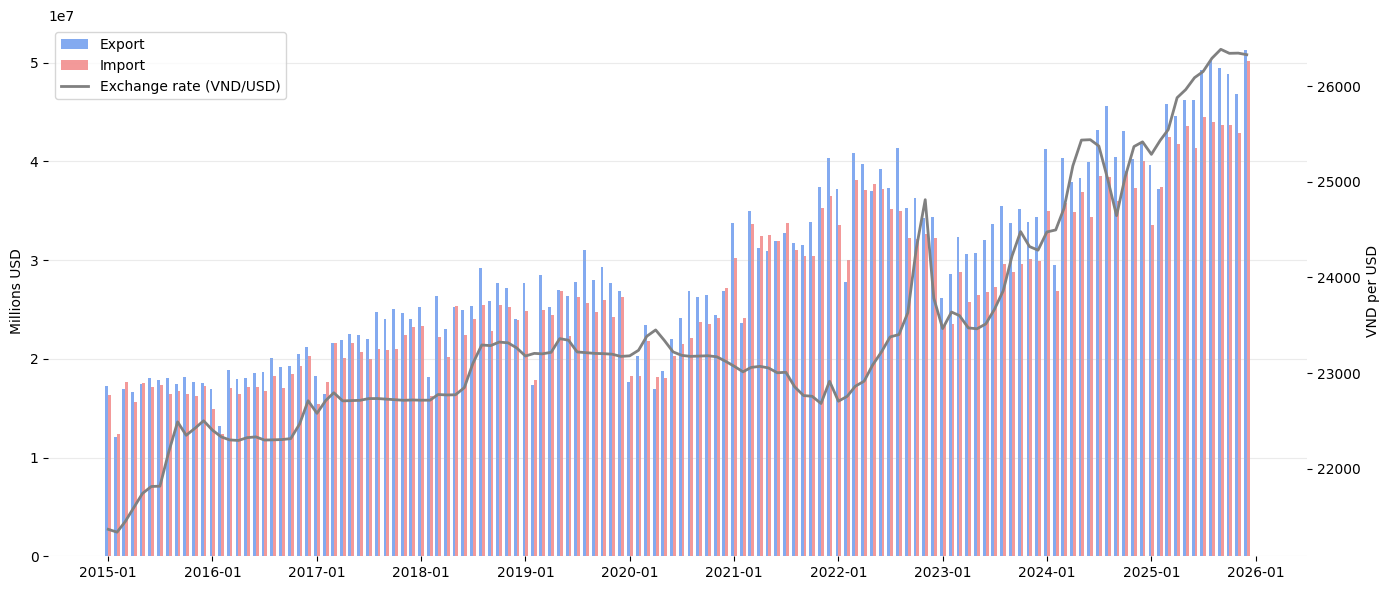

Saved → ../results/figures\ex_im_ner_timeseries.png


In [29]:
# Lọc khoảng thời gian 2015-01 → 2025-12
data_plot = data_raw.loc['2015-01-01':'2025-12-31', ['EX (USD)','IM (USD)','NER']].copy()

# Plot
fig, ax1 = plt.subplots(figsize=(14,6))

# Bỏ background figure màu đen
fig.patch.set_facecolor('white')

# Bỏ spines (viền) cho ax1
for spine in ax1.spines.values():
    spine.set_visible(False)

# Bar chart EX & IM
width = 15
ax1.bar(data_plot.index - pd.Timedelta(days=5), data_plot['EX (USD)'], width=10,
        label='Export', color='cornflowerblue', alpha=0.8)
ax1.bar(data_plot.index + pd.Timedelta(days=5), data_plot['IM (USD)'], width=10,
        label='Import', color='lightcoral', alpha=0.8)
ax1.set_ylabel('Millions USD')
ax1.grid(axis='y', alpha=0.25)

# Tạo trục thứ 2 cho NER
ax2 = ax1.twinx()
# Bỏ spines cho ax2
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.plot(data_plot.index, data_plot['NER'], color='gray', label='Exchange rate (VND/USD)', linewidth=2)
ax2.set_ylabel('VND per USD')

# Giảm số tick x cho dễ nhìn
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=10)

plt.tight_layout()

# Lưu figure
OUT_DIR = '../results/figures'
os.makedirs(OUT_DIR, exist_ok=True)
path = os.path.join(OUT_DIR,'ex_im_ner_timeseries.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')  # đảm bảo nền trắng
plt.show()
print(f'Saved → {path}')

In [32]:
# Đọc dữ liệu
df = pd.read_csv('../results/01_unit_root_test.csv')

df_table = df[['Variable','ADF Level','PP Level','Final Order']].copy()

# Đổi tên cột cho LaTeX
df_table.rename(columns={
    'ADF Level':'ADF Statistic',
    'PP Level':'PP Statistic',
    'Final Order':'Order of Integration'
}, inplace=True)

# Xuất LaTeX
latex_table = df_table.to_latex(index=False,
                                caption="Unit Root Test Results (ADF & PP)",
                                label="tab:unit_root",
                                float_format="%.4f",
                                longtable=True,
                                escape=True)

# Lưu file
output_file = "../results/unit_root_test.tex"
with open(output_file,"w") as f:
    f.write(latex_table)

print(f"LaTeX table saved to {output_file}")
print(latex_table)

LaTeX table saved to ../results/unit_root_test.tex
\begin{longtable}{llll}
\caption{Unit Root Test Results (ADF & PP)} \label{tab:unit_root} \\
\toprule
Variable & ADF Statistic & PP Statistic & Order of Integration \\
\midrule
\endfirsthead
\caption[]{Unit Root Test Results (ADF & PP)} \\
\toprule
Variable & ADF Statistic & PP Statistic & Order of Integration \\
\midrule
\endhead
\midrule
\multicolumn{4}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
ln\_FDI & -0.598 (0.871) & -3.229** (0.018) & Mixed I(0)/I(1) \\
ln\_TB & -5.103*** (0.000) & -9.342*** (0.000) & I(0) \\
ln\_EX & -1.029 (0.743) & -2.133 (0.231) & I(1) \\
ln\_IM & -1.268 (0.644) & -1.648 (0.458) & I(1) \\
ln\_RER\_pos & -7.235*** (0.000) & -6.739*** (0.000) & I(0) \\
ln\_RER\_neg & -4.890*** (0.000) & -8.397*** (0.000) & I(0) \\
IPI\_VN & -1.654 (0.455) & -2.775* (0.062) & I(1) \\
IPI\_World\_diff & -6.797*** (0.000) & -36.224*** (0.000) & I(0) \\
ln\_WTI & -2.320 (0.166) & -2.340 (0.159) & I(1